# Photo "Restoration" with Mistral — Reconstruction, Not Repair

This lab takes a damaged photograph and produces a clean one. Read the title
again before you run it: the output is a **reconstruction**, not a repair.

| Step | What happens | Powered by |
|---|---|---|
| 1 | Obtain a damaged photo (yours, or one we damage on purpose) | Pillow |
| 2 | Inspect the damage and report it | Mistral vision |
| 3 | Describe the content of the photo | Mistral vision |
| 4 | Generate a clean image from that description | Mistral `image_generation` |
| 5 | Measure how far the result drifted from the original | Pillow + vision |

## Why this notebook is shaped differently

Some providers offer **image-to-image editing**: you send the damaged file, the
model conditions on those actual pixels, and it returns a repaired version of
*your* photo. That is what a true restoration endpoint does.

Mistral's API does not currently offer that. Checking the SDK and the docs:

- the client has **no image endpoints at all** — image generation exists only as
  a tool inside the Conversations API;
- that tool is documented as **text-to-image**, with no reference-image or edit
  parameter;
- **vision is input-only** — it reads images and returns text; it cannot emit
  an image.

So the only route available is: *look at the photo, describe it, generate a new
one from the description.*

```
   damaged photo
        |
        v
  [2][3] vision  ->  "a seated woman in a dark dress, 1950s studio portrait..."
                                    |
                                    v
                      [4] image_generation  ->  A NEW PHOTOGRAPH
                                                of a similar-looking scene
```

Everything the description does not capture is **invented**. The face in the
output is not the face in the input. That is not a bug in this notebook — it is
what generation does, and Step 5 is built to make it visible rather than let you
assume otherwise.

> **Use with care.** If someone hands you a photograph of their grandmother and
> you hand back a different woman who resembles her, you have not restored
> anything. Say what you produced.

## Step 0 — Install and configure

In [1]:
!pip install --quiet "mistralai>=2.0" pillow numpy requests python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.9 MB/s eta 0:00:00


In [ ]:
"""Set up the API key, models and client."""

import base64
import os
import random
import time

import numpy as np
import requests
from PIL import Image, ImageDraw, ImageFilter
from dotenv import load_dotenv
from IPython.display import display

from mistralai.client import Mistral
from mistralai.client.models import ToolFileChunk
from mistralai.client.utils import BackoffStrategy, RetryConfig

load_dotenv()

# --------------------------------------------------------------------------
# API KEY
#   1. Colab Secrets - key icon in the left sidebar, add MISTRAL_API_KEY,
#      paste the value, switch on "Notebook access"
#   2. Environment or a .env file, when running outside Colab
#   Get a key at https://console.mistral.ai/api-keys
# --------------------------------------------------------------------------
PLACEHOLDER_PREFIX = "PASTE_YOUR_"


def read_key(name: str) -> str:
    """Return a key from Colab Secrets, then the environment, else a placeholder."""
    try:
        from google.colab import userdata          # only exists on Colab

        value = userdata.get(name)
        if value:
            return value.strip()
    except Exception:
        pass                                       # not Colab, or not granted

    return (os.getenv(name) or f"{PLACEHOLDER_PREFIX}{name}_HERE").strip()


def is_set(value: str) -> bool:
    """A key counts as usable only if it is not still the placeholder text."""
    return bool(value) and not value.startswith(PLACEHOLDER_PREFIX)


MISTRAL_API_KEY = read_key("MISTRAL_API_KEY")

# "-latest" keeps working as versions rotate. Pin an exact version for a
# reproducible assignment.
IMAGE_MODEL = "mistral-medium-latest"    # drives the image_generation tool
VISION_MODEL = "mistral-medium-latest"   # multimodal: reads an image

if not is_set(MISTRAL_API_KEY):
    raise ValueError(
        "MISTRAL_API_KEY not found.\n"
        "  Colab    : key icon in the left sidebar -> add MISTRAL_API_KEY -> "
        "turn on 'Notebook access', then re-run this cell.\n"
        "  Otherwise: create a .env file containing  MISTRAL_API_KEY=..."
    )

# --- Rate limiting --------------------------------------------------------
# Keep retries short so a depleted quota does not make a cell appear frozen.
RETRY_CONFIG = RetryConfig(
    strategy="backoff",
    backoff=BackoffStrategy(
        initial_interval=2_000, max_interval=10_000, exponent=2.0,
        max_elapsed_time=30_000, jitter_ms=500,
    ),
    retry_connection_errors=True,
    status_codes_override=["429", "500", "502", "503", "504"],
)

MIN_SECONDS_BETWEEN_CALLS = 10.0
_last_call_at = 0.0


def throttle() -> None:
    """Sleep just long enough to keep a minimum gap between API calls."""
    global _last_call_at
    wait = MIN_SECONDS_BETWEEN_CALLS - (time.time() - _last_call_at)
    if wait > 0:
        time.sleep(wait)
    _last_call_at = time.time()


client = Mistral(api_key=MISTRAL_API_KEY, retry_config=RETRY_CONFIG)

print("Client ready")
print(f"  image  : {IMAGE_MODEL}")
print(f"  vision : {VISION_MODEL}")

Client ready
  image  : mistral-medium-latest
  vision : mistral-medium-latest


## Step 1 — Get a damaged photo

Two routes, chosen automatically:

- **You uploaded one.** Put a file named `a1.png` beside the notebook and it is
  used as-is. This is the realistic case.
- **You did not.** The notebook generates a clean photograph, then damages it
  on purpose.

The second route is worth preferring while you are learning, because it gives
you something the first cannot: **the undamaged original**. Without it you have
no way to check whether the "restoration" resembles the real photo — you can
only check whether it looks plausible, which is a much weaker test.

In [4]:
# --- Step 1a: A damage simulator (pure Pillow, no API calls) --------------


def damage_photo(src_path: str, out_path: str = "damaged_photo.png", seed: int = 7):
    """Age and tear a photo: fading, fold lines, tears, a missing corner, dust.

    Deterministic for a given seed, so a class all gets the same damage.
    """
    rng = random.Random(seed)
    img = Image.open(src_path).convert("RGB")
    w, h = img.size

    # 1. Fade and yellow the print, the way a real photo ages.
    sepia = Image.new("RGB", (w, h), (196, 172, 132))
    img = Image.blend(img, sepia, 0.28)

    # 2. Soften slightly - old prints lose fine detail.
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))

    draw = ImageDraw.Draw(img)

    # 3. Fold lines: pale creases across the print.
    for frac in (0.34, 0.68):
        y = int(h * frac)
        draw.line([(0, y), (w, y)], fill=(235, 228, 210), width=3)
        draw.line([(0, y + 3), (w, y + 3)], fill=(150, 140, 120), width=1)
    x = int(w * 0.52)
    draw.line([(x, 0), (x, h)], fill=(235, 228, 210), width=3)

    # 4. Tears: jagged white gaps where the paper separated.
    for _ in range(2):
        x0 = rng.randint(int(w * 0.15), int(w * 0.85))
        points, y = [], 0
        while y < h:                       # walk down, wobbling sideways
            points.append((x0 + rng.randint(-14, 14), y))
            y += rng.randint(18, 34)
        for i in range(len(points) - 1):
            draw.line([points[i], points[i + 1]], fill=(252, 250, 245),
                      width=rng.randint(4, 9))

    # 5. A missing corner.
    draw.polygon([(w, h), (w - int(w * 0.22), h), (w, h - int(h * 0.20))],
                 fill=(252, 250, 245))

    # 6. Dust and scratches.
    for _ in range(140):
        px, py = rng.randint(0, w - 1), rng.randint(0, h - 1)
        draw.line([(px, py), (px + rng.randint(-6, 6), py + rng.randint(-6, 6))],
                  fill=(245, 240, 230), width=1)

    img.save(out_path)
    print(f"Damage applied -> {out_path}")
    return out_path

No a1.png found - generating a reference photo to damage...
Reference photo saved -> original_photo.png
Damage applied -> damaged_photo.png

Damaged photo (the input to the rest of this notebook):


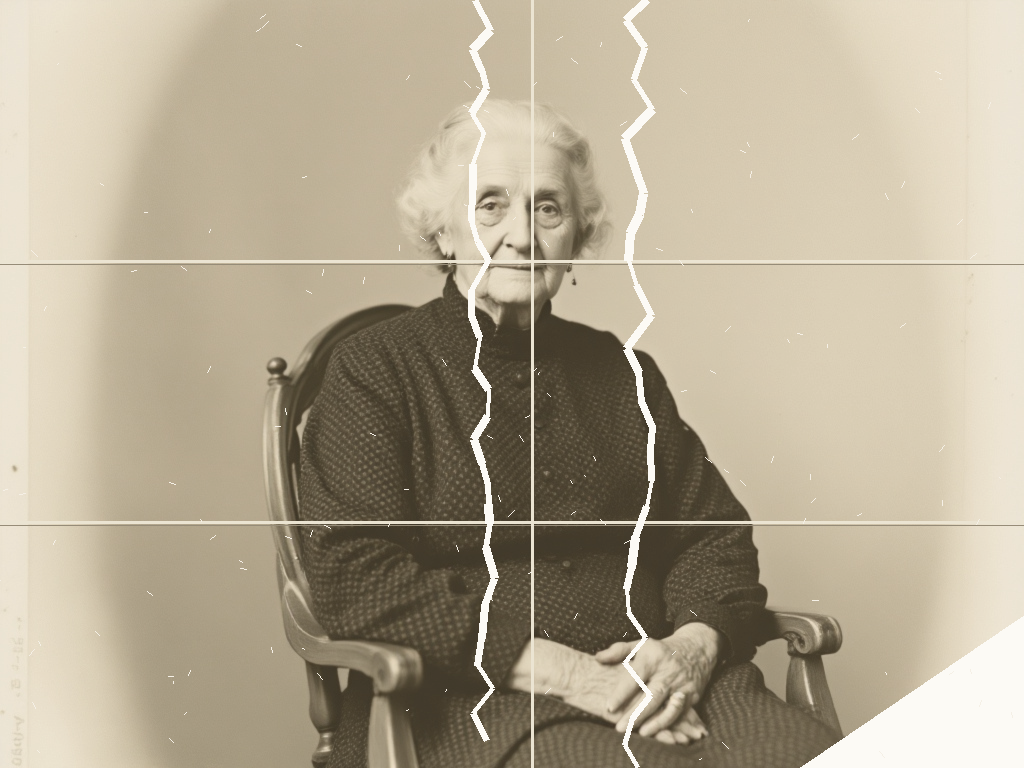

In [5]:
# --- Step 1b: Obtain the damaged photo ------------------------------------

UPLOADED_PHOTO = "a1.png"          # rename your own file to this


def _iter_chunks(response):
    """Yield every content chunk across all outputs of a conversation response."""
    for entry in getattr(response, "outputs", None) or []:
        content = getattr(entry, "content", None)
        if content is None or isinstance(content, str):
            continue
        if isinstance(content, (list, tuple)):
            yield from content
        else:
            yield content


def _is_tool_file(chunk) -> bool:
    """True if this chunk carries a generated file."""
    if isinstance(chunk, ToolFileChunk):
        return True
    return getattr(chunk, "type", None) == "tool_file" and hasattr(chunk, "file_id")


def generate_image(prompt: str, out_path: str):
    """Generate one image with the image_generation tool and save it."""
    throttle()
    response = client.beta.conversations.start(
        model=IMAGE_MODEL,
        inputs=prompt,
        tools=[{"type": "image_generation"}],   # the built-in image tool
        store=False,
    )

    commentary = [c.text for c in _iter_chunks(response)
                  if getattr(c, "type", None) == "text" and getattr(c, "text", None)]
    files = [c for c in _iter_chunks(response) if _is_tool_file(c)]
    if not files:
        raise RuntimeError("No image returned. The model said:\n"
                           + ("\n".join(commentary) or "(nothing)"))

    downloaded = client.files.download(file_id=files[0].file_id)
    data = downloaded.read() if hasattr(downloaded, "read") else bytes(downloaded)
    with open(out_path, "wb") as fh:
        fh.write(data)
    return out_path


REFERENCE_PROMPT = (
    "A vintage 1950s black and white studio portrait photograph of an elderly "
    "woman seated in a wooden chair, wearing a dark patterned dress, hands "
    "folded in her lap, plain studio backdrop, sharp focus, undamaged print."
)

if os.path.exists(UPLOADED_PHOTO):
    # Route 1: the learner supplied a photo. We have no undamaged original.
    damaged_path = UPLOADED_PHOTO
    original_path = None
    print(f"Using your uploaded photo: {UPLOADED_PHOTO}")
    print("No undamaged original available, so Step 5 can only compare")
    print("the damaged input against the reconstruction.")
else:
    # Route 2: generate a clean photo, keep it as ground truth, then damage it.
    print("No a1.png found - generating a reference photo to damage...")
    original_path = generate_image(REFERENCE_PROMPT, "original_photo.png")
    print(f"Reference photo saved -> {original_path}")
    damaged_path = damage_photo(original_path)

print("\nDamaged photo (the input to the rest of this notebook):")
display(Image.open(damaged_path))

## Step 2 — Inspect the damage

Before touching the image, ask the vision model what is wrong with it. This step
is genuinely useful on its own: a damage report is something you can act on,
file, or hand to a human conservator — and unlike Step 4, nothing here is
invented.

Images go to a vision model as content blocks alongside the text:

```python
client.chat.complete(model=..., messages=[{
    "role": "user",
    "content": [
        {"type": "text", "text": "What's in this image?"},
        {"type": "image_url", "image_url": "data:image/png;base64,..."},
    ],
}])
```

In [ ]:
# --- Step 2: Ask vision to report the damage ------------------------------

DAMAGE_PROMPT = (
    "You are a photograph conservator examining a damaged print. "
    "List only the physical defects you can actually see: tears, creases or "
    "fold lines, missing areas, fading, discolouration, scratches, dust, blur. "
    "For each, say roughly where it is in the frame. "
    "Use short bullet points. Do not describe the subject of the photograph, "
    "and do not suggest repairs."
)


def image_to_data_uri(path: str) -> str:
    """Read a local image and encode it as a base64 data URI."""
    suffix = path.rsplit(".", 1)[-1].lower()
    mime = "image/jpeg" if suffix in ("jpg", "jpeg") else f"image/{suffix}"
    with open(path, "rb") as fh:
        return f"data:{mime};base64," + base64.b64encode(fh.read()).decode("utf-8")


def ask_vision(path: str, prompt: str, temperature: float = 0.2) -> str:
    """Send one image plus a prompt to the vision model, return its text."""
    throttle()
    response = client.chat.complete(
        model=VISION_MODEL,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": image_to_data_uri(path)},
            ],
        }],
        temperature=temperature,      # low: we want description, not invention
        retries=0,                    # report a 429 immediately; do not wait through SDK backoff
    )
    return response.choices[0].message.content.strip()


try:
    damage_report = ask_vision(damaged_path, DAMAGE_PROMPT)
except Exception as exc:
    damage_report = ""
    error_text = str(exc)
    if "429" in error_text or "rate_limit" in error_text.lower():
        print("Vision request was rate-limited by Mistral (HTTP 429).")
        print("The request format is valid, but this API key/model quota is currently unavailable.")
        print("Check Mistral usage/limits or try again later, then rerun this cell only.")
    else:
        print(f"Vision inspection failed: {type(exc).__name__}: {error_text[:200]}")

print("DAMAGE REPORT")
print("=" * 60)
print(damage_report or "(No report available - rerun Step 2 after the quota clears.)")

SDKError: API error occurred: Status 429. Body: {"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}

## Step 3 — Describe the content

Now a second, separate question: what is actually *in* the photograph?

This is the only information that will survive into Step 4. Whatever the
description leaves out, the generator will invent. Reading this text carefully
is the single most useful thing you can do in this notebook — it is a preview of
exactly how much of the original is about to be thrown away.

Note what the prompt asks the model to ignore: the damage. We want a description
of the photograph as it was, not as it is now.

In [ ]:
# --- Step 3: Ask vision to describe the content ---------------------------

CONTENT_PROMPT = (
    "Describe the photograph this print shows, ignoring all physical damage "
    "(tears, creases, fading, missing areas). "
    "Cover: how many people and their approximate ages, their posture and where "
    "they are looking, clothing and hairstyles, objects and furniture, the "
    "setting and background, the framing and camera angle, and the lighting. "
    "Write one paragraph of plain description, at most 120 words. "
    "Do not guess names, dates, places or emotions. "
    "Do not mention the damage or the condition of the print."
)

content_description = ask_vision(damaged_path, CONTENT_PROMPT)

print("CONTENT DESCRIPTION")
print("=" * 60)
print(content_description)
print()
print(f"({len(content_description.split())} words - everything not stated here")
print(" will be invented in Step 4.)")

## Step 4 — Generate a clean photograph

The description from Step 3 goes to `image_generation`, together with
instructions about the *style* of print we want back.

Be clear about what this call receives: **a paragraph of text**. The damaged
photo is not attached. The pixels of the original never reach the generator.
Whatever comes back is a fresh photograph that matches a written description —
not your photograph with its tears mended.

In [ ]:
# --- Step 4: Generate a clean photograph from the description -------------

RESTORE_PROMPT_TEMPLATE = (
    "Generate a clean, undamaged photograph showing exactly this scene:\n\n"
    "{description}\n\n"
    "Render it as a well-preserved archival photographic print: sharp focus, "
    "even tonal range, no tears, no creases, no fading, no missing areas, "
    "no dust or scratches. Keep the original framing and camera angle. "
    "Do not add people, objects or text that were not described."
)

reconstruction_path = generate_image(
    RESTORE_PROMPT_TEMPLATE.format(description=content_description),
    "reconstructed_photo.png",
)

print(f"Reconstruction saved -> {reconstruction_path}\n")
display(Image.open(reconstruction_path))

## Step 5 — Measure the drift

The reconstruction probably looks good. That is precisely the problem: a
plausible output invites you to skip the check.

Three comparisons, weakest to strongest:

1. **Look at them side by side.** Cheap and often sufficient.
2. **Ask vision what differs.** The model that described the photo can also
   compare the two, and it will name specific changes you might gloss over.
3. **Measure appearance numerically.** Crude, and honestly labelled as such —
   these numbers capture colour and layout, not identity.

In [ ]:
# --- Step 5a: Put the images side by side ---------------------------------


def contact_sheet(paths_and_labels, height: int = 320):
    """Compose labelled images into one row for easy comparison."""
    from PIL import ImageFont

    images = []
    for path, label in paths_and_labels:
        if path is None or not os.path.exists(path):
            continue
        im = Image.open(path).convert("RGB")
        w = int(im.width * height / im.height)
        images.append((im.resize((w, height)), label))

    if not images:
        return None

    pad, caption_h = 10, 26
    total_w = sum(im.width for im, _ in images) + pad * (len(images) + 1)
    sheet = Image.new("RGB", (total_w, height + caption_h + pad * 2), (255, 255, 255))
    draw = ImageDraw.Draw(sheet)
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None

    x = pad
    for im, label in images:
        sheet.paste(im, (x, pad))
        draw.text((x + 2, pad + height + 6), label, fill=(20, 20, 20), font=font)
        x += im.width + pad
    return sheet


sheet = contact_sheet([
    (original_path, "1. ORIGINAL (ground truth)"),
    (damaged_path, "2. DAMAGED (the input)"),
    (reconstruction_path, "3. RECONSTRUCTION (generated)"),
])

if sheet:
    display(sheet)

if original_path is None:
    print("\nNo undamaged original is available, because you supplied your own")
    print("photo. You can judge whether the reconstruction looks plausible, but")
    print("not whether it is faithful. Those are different questions.")

In [ ]:
# --- Step 5b: Ask vision what actually differs ----------------------------

DIFF_PROMPT = (
    "These are two photographs of a similar scene. "
    "List the concrete visual differences between them: people (count, age, "
    "face, pose, gaze), clothing, objects, background, framing and lighting. "
    "Be specific and factual. If a person's face appears to be a different "
    "individual, say so plainly. Use short bullet points."
)


def compare_images(path_a: str, path_b: str) -> str:
    """Send two images in one message and ask what differs."""
    throttle()
    response = client.chat.complete(
        model=VISION_MODEL,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": DIFF_PROMPT},
                {"type": "image_url", "image_url": image_to_data_uri(path_a)},
                {"type": "image_url", "image_url": image_to_data_uri(path_b)},
            ],
        }],
        temperature=0.2,
    )
    return response.choices[0].message.content.strip()


# Compare against the original when we have one, otherwise the damaged input.
baseline_path = original_path or damaged_path
baseline_name = "ORIGINAL" if original_path else "DAMAGED INPUT"

try:
    differences = compare_images(baseline_path, reconstruction_path)
    print(f"WHAT CHANGED  ({baseline_name} -> RECONSTRUCTION)")
    print("=" * 60)
    print(differences)
except Exception as exc:
    print(f"Comparison skipped ({type(exc).__name__}: {str(exc)[:120]})")
    print("Re-run this cell to try again.")

In [ ]:
# --- Step 5c: Crude appearance metrics ------------------------------------
# These compare COLOUR and LAYOUT. They cannot tell you whether the person in
# the reconstruction is the same person. Treat them as a smoke test only.


def appearance_metrics(path_a: str, path_b: str, size: int = 256):
    """Return (rmse, histogram_correlation) between two images.

    rmse                 0.0 = pixel-identical, larger = more different
    histogram_correlation 1.0 = same colour distribution, 0.0 = unrelated
    """
    a = np.asarray(Image.open(path_a).convert("RGB").resize((size, size)), float) / 255
    b = np.asarray(Image.open(path_b).convert("RGB").resize((size, size)), float) / 255

    rmse = float(np.sqrt(((a - b) ** 2).mean()))

    correlations = []
    for channel in range(3):
        ha, _ = np.histogram(a[..., channel], bins=32, range=(0, 1))
        hb, _ = np.histogram(b[..., channel], bins=32, range=(0, 1))
        ha, hb = ha / max(ha.sum(), 1), hb / max(hb.sum(), 1)
        if ha.std() == 0 or hb.std() == 0:
            correlations.append(0.0)
        else:
            correlations.append(float(np.corrcoef(ha, hb)[0, 1]))

    return rmse, float(np.mean(correlations))


print(f"{'comparison':<38} {'RMSE':>8} {'hist corr':>10}")
print("-" * 58)

if original_path:
    r, c = appearance_metrics(original_path, damaged_path)
    print(f"{'original  vs damaged':<38} {r:>8.4f} {c:>10.4f}")
    r, c = appearance_metrics(original_path, reconstruction_path)
    print(f"{'original  vs reconstruction':<38} {r:>8.4f} {c:>10.4f}")

r, c = appearance_metrics(damaged_path, reconstruction_path)
print(f"{'damaged   vs reconstruction':<38} {r:>8.4f} {c:>10.4f}")

print()
print("Read these as a smoke test, not a verdict. A low RMSE means the two")
print("images have similar colours in similar places. It does NOT mean the")
print("reconstruction preserved anyone's identity - only your eyes and the")
print("difference report in Step 5b speak to that.")

---

# What this notebook actually demonstrates

**Vision is the reliable half.** Steps 2 and 3 read the photograph and report
what is there. Nothing is fabricated, the output is checkable against the image
in front of you, and a damage report is useful on its own.

**Generation is the unreliable half — by design.** Step 4 received a paragraph
of text and nothing else. It produced a photograph consistent with that
paragraph. Consistency with a description is not fidelity to an original, and no
amount of prompt tuning closes that gap, because the pixels never reached the
generator.

**The gap is invisible unless you look for it.** A reconstruction of a photo you
have never seen looks like a restoration. That is why Step 5 exists, and why the
synthetic route — where you keep the undamaged original — is the better teaching
setup: it is the only version where "did this work?" has a real answer.

## When is this acceptable?

| Use | Verdict | Why |
|---|---|---|
| Damage assessment and cataloguing | **Yes** | Steps 2–3 only. Descriptive, checkable, invents nothing |
| Illustrating what a scene *might* have looked like | **Yes, if labelled** | Honest reconstruction, clearly captioned as generated |
| Concept art, mood boards, teaching material | **Yes** | Nobody is claiming the output is a record |
| Restoring a family photograph to keep or print | **No** | The face will not be the same person |
| Anything evidential — journalism, legal, historical record, insurance | **No** | A generated image is not evidence of anything |

The rule is simple: **a generated image may illustrate, but it may never
testify.** If the output could be mistaken for a record of something that
happened, label it, or do not produce it.

## Things to try

1. **Read Step 3, then cover the screen and predict Step 4.** What did the
   description fail to pin down? Those are the details the model will invent.
2. **Run Step 4 three times unchanged.** How much do the outputs differ from one
   another? Anything that varies between runs was never in the original — it was
   invented each time.
3. **Starve the description.** Cap `CONTENT_PROMPT` at 30 words and regenerate.
   Watch the drift grow, and note that the output still looks equally convincing.
4. **Enrich it.** Ask Step 3 for face shape, hair parting, collar style, exact
   pose. Does more detail actually reduce the drift, or just produce a more
   confident-looking wrong answer?
5. **Damage it differently.** Change the `seed` in `damage_photo`, or raise the
   tear count. At what point does vision stop being able to describe the content
   at all? That failure point is more useful to know than any success.
6. **Try the honest alternative.** Classical inpainting (OpenCV's
   `cv2.inpaint`) repairs actual pixels and invents nothing outside the damaged
   mask. Compare its output with Step 4's. Which would you hand to a family?

## Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| `MISTRAL_API_KEY not found` | No key in Colab Secrets, env or `.env` | Key icon in the left sidebar → add `MISTRAL_API_KEY` → turn on **Notebook access** → re-run the config cell |
| `SDKError: Status 429` | Free-tier rate limit; this notebook makes several heavy calls | Already retried with backoff. If it persists, raise `MIN_SECONDS_BETWEEN_CALLS` to 5 and re-run **only** the failed cell |
| `No image returned. The model said: ...` | The generator declined | Read the printed message. Portraits of specific real people are commonly refused — use the synthetic route |
| Step 5b returns a vague answer | Two images in one message is demanding | Lower `temperature`, or ask about one aspect at a time (faces, then clothing, then background) |
| Reconstruction ignores the framing | The description did not state it | Add framing and camera angle to `CONTENT_PROMPT` |
| Your own `a1.png` gives poor results | Heavy damage leaves little for vision to read | Expected, and worth reporting. Try the synthetic route to see the contrast |

## A note on the key

**On Colab**, use Secrets rather than pasting the key into a cell: key icon in
the left sidebar, add `MISTRAL_API_KEY`, paste the value, switch on **Notebook
access**. Secrets live in your Google account, not in the `.ipynb`, so the
notebook stays safe to share and to submit.

**Outside Colab**, use a `.env` file beside the notebook, listed in
`.gitignore`:

```
MISTRAL_API_KEY=...
```